<a href="https://colab.research.google.com/github/maxF10R35/Estudio-Aguacates-Monarca/blob/main/ARIMA_PP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Modelo ARIMA

----Colocar aquí la explicación de los datos---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Visualizamos la serie de tiempo
df = pd.read_csv('/content/serie_tiempo_precio_kg_2001_2026.csv')
df.tail()

,anio,mes,Precio_Promedio_kg
298,2025,12,46.63
299,2026,1,43.51
300,2026,2,41.99
301,2026,3,44.63
302,2026,4,46.32


In [ ]:
df['fecha'] = pd.to_datetime(
    df[['anio', 'mes']]
    .rename(columns={'anio': 'year', 'mes': 'month'})
    .assign(day=1)
)

print(df)

     anio  mes  Precio_Promedio_kg      fecha
0    2001    1               12.81 2001-01-01
1    2001    2               13.01 2001-02-01
2    2001    3               13.03 2001-03-01
3    2001    4               13.34 2001-04-01
4    2001    5               14.99 2001-05-01
..    ...  ...                 ...        ...
298  2025   12               46.63 2025-12-01
299  2026    1               43.51 2026-01-01
300  2026    2               41.99 2026-02-01
301  2026    3               44.63 2026-03-01
302  2026    4               46.32 2026-04-01

[303 rows x 4 columns]


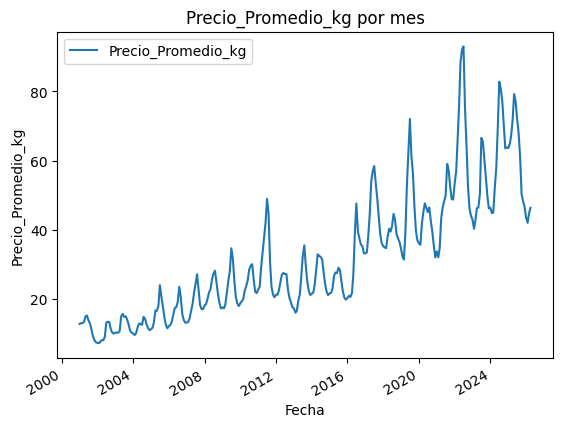

In [ ]:
#Graficamos los valores para ver cómo se comporta la serie de tiempo
df.plot(x='fecha', y='Precio_Promedio_kg')
plt.title('Precio_Promedio_kg por mes')
plt.xlabel('Fecha')
plt.ylabel('Precio_Promedio_kg')
plt.show()


In [ ]:
# Seleccionamos la Fecha como el índice del DataFrame y ordenamos por esta
df.set_index('fecha', inplace=True)
df.sort_index(inplace=True)
df.head()

,anio,mes,Precio_Promedio_kg
fecha,,,
2001-01-01,2001,1,12.81
2001-02-01,2001,2,13.01
2001-03-01,2001,3,13.03
2001-04-01,2001,4,13.34
2001-05-01,2001,5,14.99


In [ ]:
# Establecemos la frecuencia de los datos de forma explícita
df = df.asfreq('MS')
#localizamos los valores nulos
df[df['Precio_Promedio_kg'].isnull()]

,anio,mes,Precio_Promedio_kg
fecha,,,
2020-06-01,NaN,NaN,NaN


In [ ]:
# Rellena el NaN usando interpolación lineal
df['Precio_Promedio_kg'] = df['Precio_Promedio_kg'].interpolate(method='linear')

In [ ]:
#Contamos los valores nulos
print(df.isnull().sum())
df.loc['2020-06-01']

anio                  1
mes                   1
Precio_Promedio_kg    0
dtype: int64


,2020-06-01
anio,NaN
mes,NaN
Precio_Promedio_kg,46.37


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


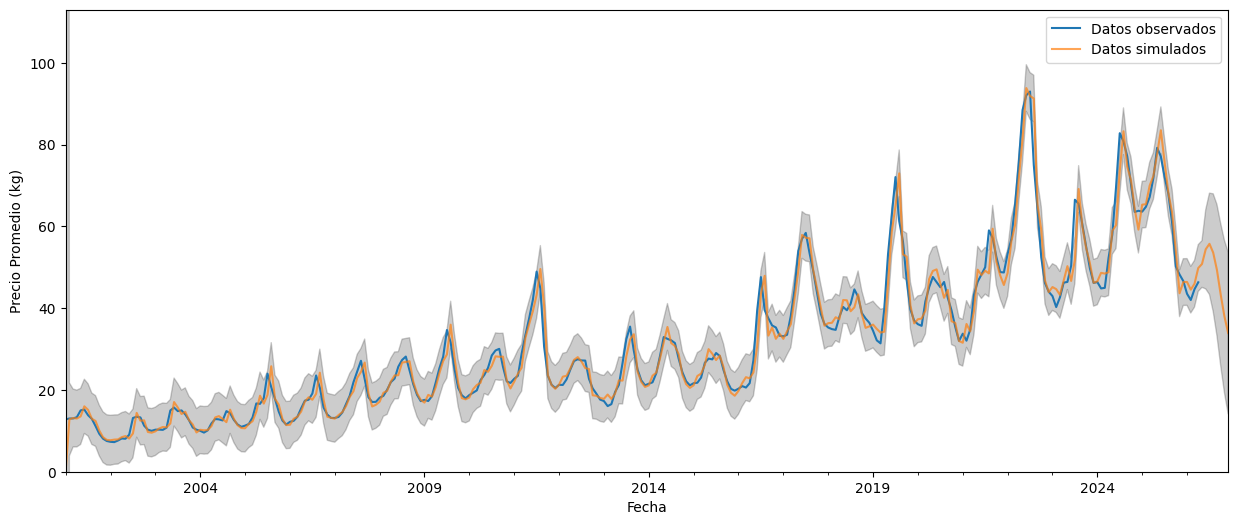

"\n# Crea el DataFrame a partir de un diccionario que contiene pred.predicted_mean\ndf_pred = pd.DataFrame({'Precios simulados': pred.predicted_mean})\ndf_pred.to_excel('datos_simulados.xlsx')"

In [ ]:
mod = ARIMA(df['Precio_Promedio_kg'], order=(3,1,4))
res = mod.fit()
res.summary()
# Generamos las predicciones y su intervalo de confianza
pred = res.get_prediction(start=pd.to_datetime('2001-01-01'), end=pd.to_datetime('2026-12-01'), dynamic=False)
pred_ci = pred.conf_int()
# Creamos el gráfico
ax = df['Precio_Promedio_kg']['2001':].plot(label='Datos observados')
pred.predicted_mean.plot(ax=ax, label='Datos simulados', alpha=.7, figsize=(15, 6))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_ylim([0, df['Precio_Promedio_kg'].max() + 20])
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio Promedio (kg)')
plt.legend()
plt.show()
'''
# Crea el DataFrame a partir de un diccionario que contiene pred.predicted_mean
df_pred = pd.DataFrame({'Precios simulados': pred.predicted_mean})
df_pred.to_excel('datos_simulados.xlsx')'''

In [ ]:
#COEFICIENTE DE CORRELACIÓN Y ERROR CUADRATICO
pred = res.get_prediction(start=pd.to_datetime('2001-01-01'), end=pd.to_datetime('2026-04-01'), dynamic=False)
pred_ci = pred.conf_int()
# Cálculo del MSE y R2
mse = mean_squared_error(df['Precio_Promedio_kg'][pred.predicted_mean.index[0]:pred.predicted_mean.index[-1]], pred.predicted_mean)
r2 = r2_score(df['Precio_Promedio_kg'][pred.predicted_mean.index[0]:pred.predicted_mean.index[-1]], pred.predicted_mean)
print(f"El error cuadrático medio (MSE) es: {mse}")
print(f"El coeficiente de determinación (R2) es: {r2}")

El error cuadrático medio (MSE) es: 9.087501232075246
El coeficiente de determinación (R2) es: 0.9730786738456174
